# Customer Churn Analysis & Business Intelligence Dashboard

**Business Analyst Case Study** — Telco Customer Churn Dataset

This notebook walks through the full analysis: business problem, data cleaning, exploratory analysis, business KPIs, and an optional baseline predictive model.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("../data/telco_churn.csv")
print(f"Loaded {len(df)} rows, {len(df.columns)} columns.")
df.head()

Loaded 7043 rows, 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Cleaning

Steps: duplicate removal, datatype correction (TotalCharges), missing value handling, outlier flagging, and feature engineering (tenure groups).

In [3]:
df = df.drop_duplicates(subset="customerID")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])

df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

bins = [0, 6, 12, 24, 48, 72]
labels = ["0-6 mo", "6-12 mo", "1-2 yr", "2-4 yr", "4-6 yr"]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

print("Missing values after cleaning:")
print(df.isna().sum().sum())

Missing values after cleaning:
0


## 4. Business KPIs

In [4]:
total_customers = len(df)
churned = df["Churn_Flag"].sum()
churn_rate = churned / total_customers * 100
avg_tenure = df["tenure"].mean()
avg_charges = df["MonthlyCharges"].mean()
revenue_lost = df.loc[df["Churn_Flag"] == 1, "MonthlyCharges"].sum() * 12
clv = avg_charges * avg_tenure

print(f"Total Customers: {total_customers:,}")
print(f"Churn Rate: {churn_rate:.1f}%")
print(f"Avg Tenure: {avg_tenure:.1f} months")
print(f"Estimated Annual Revenue Lost: ${revenue_lost:,.2f}")
print(f"Estimated CLV: ${clv:,.2f}")

Total Customers: 7,043
Churn Rate: 26.5%
Avg Tenure: 32.4 months
Estimated Annual Revenue Lost: $1,669,570.20
Estimated CLV: $2,096.41


## 5. Exploratory Data Analysis

### 5.1 Churn by Contract Type

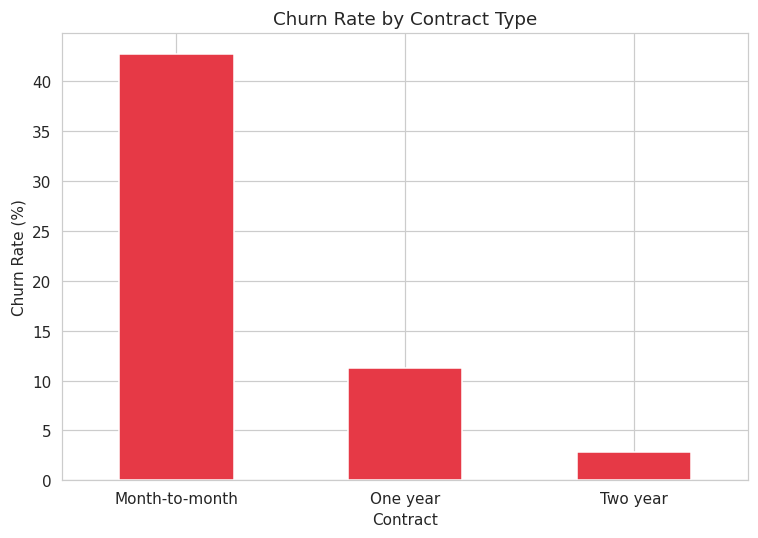

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_Flag, dtype: float64

In [5]:
contract_churn = df.groupby("Contract")["Churn_Flag"].mean().sort_values(ascending=False) * 100
ax = contract_churn.plot(kind="bar", color="#E63946", figsize=(7,5))
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Contract Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
contract_churn

**Insight:** Month-to-month customers churn at a dramatically higher rate than customers on longer contracts — the strongest single driver in the dataset.

### 5.2 Churn by Tenure

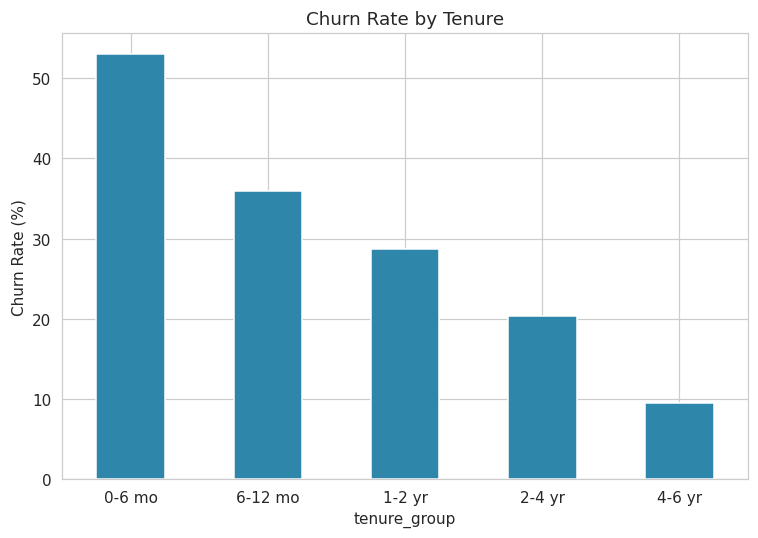

tenure_group
0-6 mo     52.937205
6-12 mo    35.886525
1-2 yr     28.710938
2-4 yr     20.388959
4-6 yr      9.513176
Name: Churn_Flag, dtype: float64

In [6]:
tenure_churn = df.groupby("tenure_group", observed=True)["Churn_Flag"].mean() * 100
ax = tenure_churn.plot(kind="bar", color="#2E86AB", figsize=(7,5))
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Tenure")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
tenure_churn

**Insight:** Churn risk is highest in the first 6 months and declines steadily as tenure increases — onboarding is a critical intervention window.

### 5.3 Correlation Heatmap

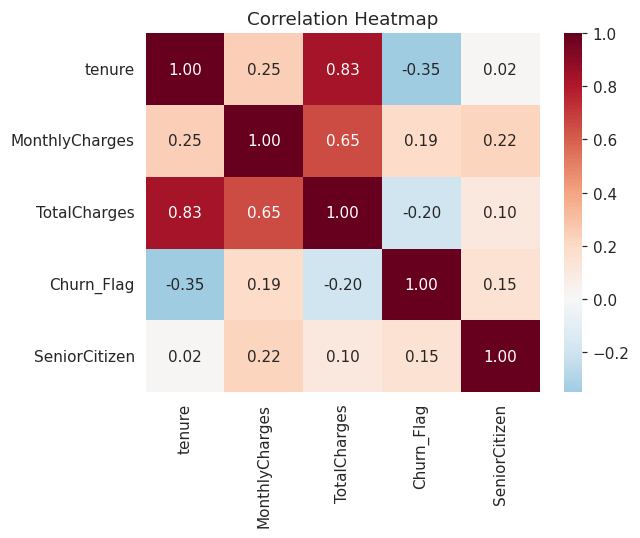

In [7]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_Flag", "SeniorCitizen"]
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 6. Optional: Baseline Predictive Model

A simple logistic regression, included as an optional extension. The project's core value is the business analysis above, not predictive modeling.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_df = df.copy()
cat_cols = model_df.select_dtypes(include="object").columns.drop(["customerID", "Churn"])
le = LabelEncoder()
for col in cat_cols:
    model_df[col] = le.fit_transform(model_df[col])

features = ["tenure", "MonthlyCharges", "TotalCharges", "Contract",
            "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]
X = model_df[features]
y = model_df["Churn_Flag"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Baseline model accuracy: {acc:.1%}")

/tmp/ipykernel_774/1076094208.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = model_df.select_dtypes(include="object").columns.drop(["customerID", "Churn"])


Baseline model accuracy: 78.5%
